# Task 2 - Customer Segmentation Analysis

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** Online Retail Dataset (UCI/Kaggle) — ~540,000 transactions from a UK-based online retailer, Dec 2010 - Dec 2011.

**Tools:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Dataset/OnlineRetail.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Load Dataset and Inspect Structure

In [2]:
print("Shape (rows, columns):", df.shape)

print("\nData types:\n")
print(df.info())

print("\nMissing values per column:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive stats for Quantity and UnitPrice:\n")
print(df[["Quantity", "UnitPrice"]].describe())

Shape (rows, columns): (541909, 8)

Data types:

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None

Missing values per column:

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Descriptive stats for Quantity and UnitPrice:

            Quantity      UnitPrice
count  541909.000000  541909.00000

### Data Cleaning for Clustering

Before building customer-level features, three cleaning steps are needed:

1. **Drop rows with missing CustomerID** (~135,000 rows, ~25% of data). Since clustering happens at the customer level, transactions without a CustomerID cannot be assigned to any customer and must be excluded.
2. **Remove cancelled/returned orders.** InvoiceNo values starting with "C" indicate cancellations, and these typically have negative Quantity. These aren't genuine purchases and would distort purchase-frequency and monetary calculations.
3. **Drop rows with missing Description** — a small number (1,454) and not usable for customer-level aggregation anyway.

In [3]:
# Step 1: Drop missing CustomerID
df_clean = df.dropna(subset=["CustomerID"]).copy()

# Step 2: Remove cancelled orders (InvoiceNo starting with 'C') and negative/zero quantities
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Step 3: Drop missing Description (if any remain)
df_clean = df_clean.dropna(subset=["Description"])

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)
print("\nRemaining missing values:\n", df_clean.isnull().sum())

Before cleaning: (541909, 8)
After cleaning: (397884, 8)

Remaining missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


**Result:** Cleaning removed 144,025 rows (~26.6%), primarily due to missing CustomerID and cancelled orders. The remaining 397,884 rows are genuine, complete purchase transactions ready for customer-level aggregation.

### Feature Engineering: RFM Analysis

We calculate Recency, Frequency, and Monetary value per customer — the standard behavioural features for customer segmentation.

In [4]:
# Create a TotalPrice column
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Set a reference date (one day after the last transaction in the dataset)
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("Number of unique customers:", rfm.shape[0])
rfm.head(10)

Number of unique customers: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


### Descriptive Statistics on RFM

Average purchase value, purchase frequency, and customer lifetime value across the customer base.

In [5]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


**Observation:** All three RFM features are heavily right-skewed. The typical customer (median) bought only 2 times, spent ₹674, and last purchased 51 days ago — but a small group of outliers stretches the averages way up (max Monetary is ₹280,206, max Frequency is 209 orders). This skew is exactly why we standardize the features before clustering — otherwise Monetary's large scale would dominate the distance calculations K-Means uses.

### Standardization and Elbow Method

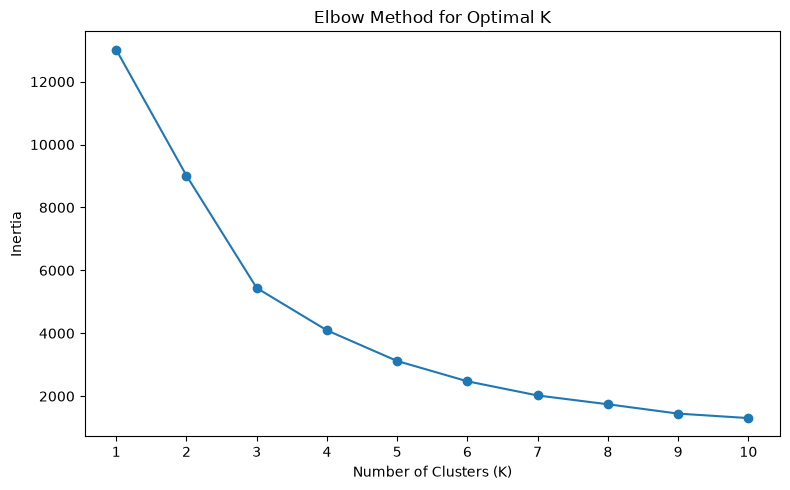

In [6]:
# Standardize the RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# Elbow Method: try K from 1 to 10
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.tight_layout()
plt.savefig("Images/elbow_method.png", dpi=150)
plt.show()

**Observation:** The elbow point occurs at **K=4** — inertia drops sharply from K=1 to K=4, then the rate of decrease flattens noticeably. Beyond 4 clusters, adding more groups provides only marginal improvement, so **K=4** is chosen as the optimal number of customer segments.

### Apply K-Means Clustering (K=4)

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

### Visualize Clusters

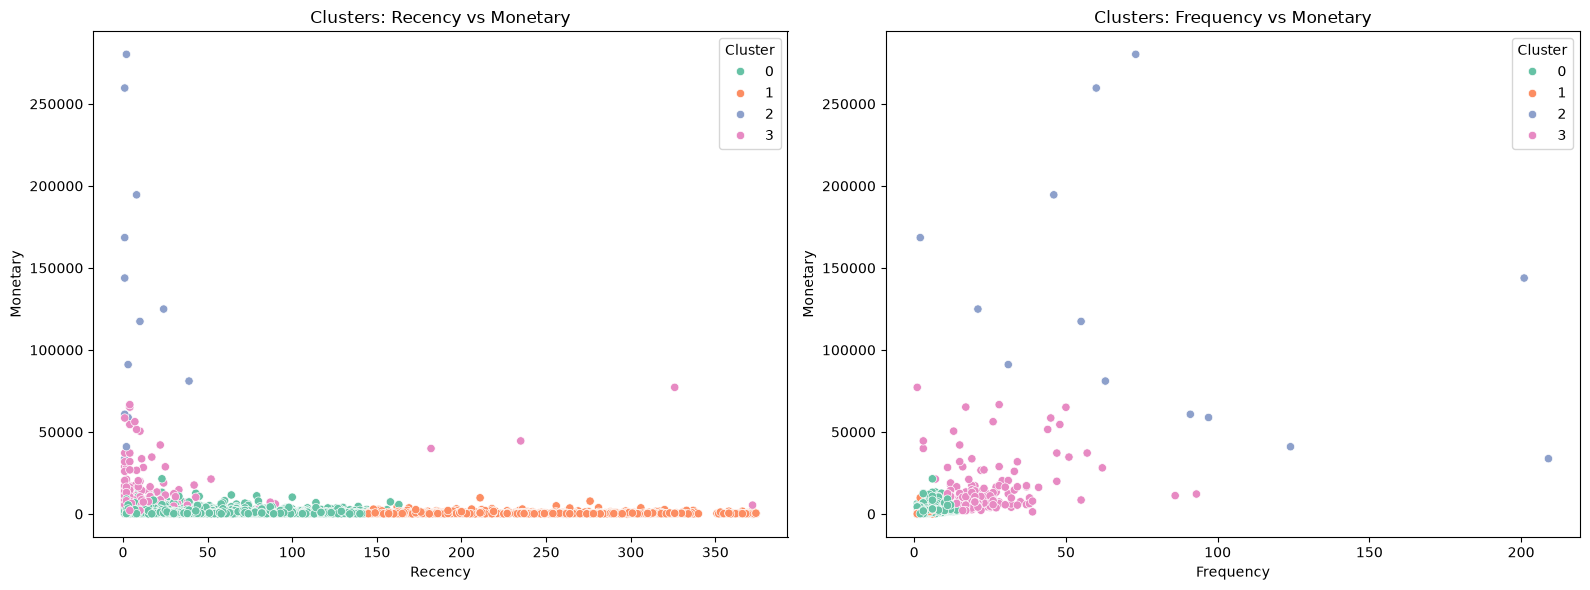

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[0])
axes[0].set_title("Clusters: Recency vs Monetary")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[1])
axes[1].set_title("Clusters: Frequency vs Monetary")

plt.tight_layout()
plt.savefig("Images/cluster_scatterplots.png", dpi=150)
plt.show()

In [9]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_profile["Count"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,43.70,3.68,1359.05,3054
1,248.08,1.55,480.62,1067
2,7.38,82.54,127338.31,13
3,15.50,22.33,12709.09,204


### Cluster Profiles & Customer Types

| Cluster | Recency (days) | Frequency | Monetary | Count | Customer Type |
|---|---|---|---|---|---|
| 0 | 43.7 | 3.68 | ₹1,359 | 3,054 | **Regular Customers** — bought fairly recently, moderate frequency and spend. The backbone of the customer base. |
| 1 | 248.1 | 1.55 | ₹481 | 1,067 | **At-Risk / Churned Customers** — haven't purchased in ~8 months, low frequency and spend. Likely to be lost without intervention. |
| 2 | 7.4 | 82.54 | ₹127,338 | 13 | **VIP / Champion Customers** — extremely frequent buyers with very high spend, purchased very recently. Tiny in number but almost certainly a disproportionate share of total revenue. |
| 3 | 15.5 | 22.33 | ₹12,709 | 204 | **Loyal High-Value Customers** — buy often, spend well, and are recently active. A step below VIPs but still highly valuable. |

### Number of Customers per Cluster

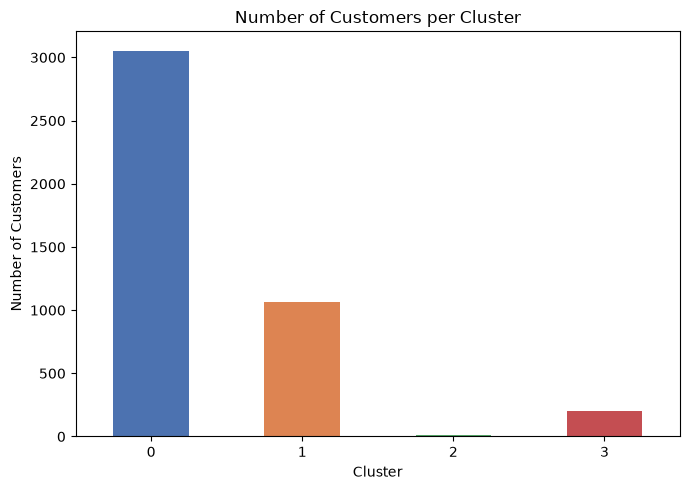

In [10]:
plt.figure(figsize=(7, 5))
cluster_profile["Count"].plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/cluster_sizes.png", dpi=150)
plt.show()

## Insights & Marketing Recommendations

The 4 clusters reveal a classic customer value pyramid, with a tiny fraction of customers driving disproportionate value:

**Cluster 2 — VIP/Champions (13 customers, ₹127,338 avg spend)**
Recommendation: Assign dedicated account management, early access to new products, and personalized loyalty perks. Losing even one of these customers has an outsized revenue impact, so retention here should be a top priority despite the small headcount.

**Cluster 3 — Loyal High-Value (204 customers, ₹12,709 avg spend)**
Recommendation: Nurture toward VIP status with tiered loyalty rewards, exclusive discounts, and bundle offers. This is the most promising growth segment — moving even a portion of these customers into Cluster 2 would meaningfully grow revenue.

**Cluster 0 — Regular Customers (3,054 customers, ₹1,359 avg spend)**
Recommendation: This is the largest segment and the core of the business. Use regular email campaigns, seasonal promotions, and cross-sell recommendations to increase purchase frequency and gradually shift more of this group toward Cluster 3.

**Cluster 1 — At-Risk/Churned (1,067 customers, ₹481 avg spend, inactive ~248 days)**
Recommendation: Launch a win-back campaign with a targeted discount or "we miss you" offer. Given the size of this group (nearly 25% of all customers), even a modest reactivation rate would meaningfully grow revenue. If reactivation fails after outreach, deprioritize further marketing spend on this group.

**Overall takeaway:** Revenue is highly concentrated — the combined 217 customers in Clusters 2 and 3 (~5% of the customer base) likely account for a large share of total revenue, reinforcing the value of prioritizing retention over acquisition for this business.